# Baseline Models

In [ ]:
import os, sys, warnings
warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from src.features import build_features, TIER_COLUMNS, feature_set
from src.models import load_features, split, train_eval, add_lr_polynomial_features, LR_POLY_FEATURES

sns.set_style('whitegrid'); plt.rcParams['figure.dpi'] = 100


## 1. Loading engineered features and split


In [ ]:
df = load_features()
print(f'Total: {len(df):,} shots, base rate {df["goal"].mean():.3f}')

df = add_lr_polynomial_features(df)

train, test = split(df)
print(f'Train: {len(train):,}  Test: {len(test):,}')
print(f'Goal rate - train: {train["goal"].mean():.3f}, test: {test["goal"].mean():.3f}')


Total: 86,563 shots, base rate 0.101
Train: 69,250  Test: 17,313
Goal rate — train: 0.101, test: 0.101


## 2. The model roster

We test out 4 models here: Logistic Regression, Naive Bayes, Decision Tree, Random Forest

For LR we wrap the classifier in a pipeline with `StandardScaler`. Without scaling, the regularization penalty would be dominated by the high-variance features (distance², GK distances) and the one-hot dummies would be drowned out.

Tree models and Naive Bayes don't need scaling.

In [ ]:
def make_lr():
    return Pipeline([
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs')),
    ])

def make_nb():
    return GaussianNB()

def make_dt():
    return DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=42)

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=20,
        n_jobs=-1, random_state=42,
    )

T1 = feature_set('tier1')
T12 = feature_set('tier1', 'tier2')
T123 = feature_set('tier1', 'tier2', 'tier3')
T1234 = feature_set('tier1', 'tier2', 'tier3', 'tier4')
T12345 = feature_set('tier1', 'tier2', 'tier3', 'tier4', 'tier5')

print(f'Tier 1: {len(T1)} features')
print(f'Tier 1+2: {len(T12)} features')
print(f'Tier 1+2+3: {len(T123)} features')
print(f'Tier 1+2+3+4: {len(T1234)} features')
print(f'Tier 1+2+3+4+5 (all): {len(T12345)} features')


Tier 1   : 2 features
Tier 1+2 : 32 features
Tier 1+2+3 : 39 features
Tier 1+2+3+4 : 47 features
Tier 1+2+3+4+5 (all): 57 features


## 3. Logistic Regression

We will first test out the most simplest xG models. These are also the most common ones used.

1. Logistic Regression with only `distance_to_goal` and `angle_to_goal`. This is the strictest possible baseline. The other models must beat it.
2. We also try adding interaction terms like `distance²`, `log(distance)`,`distance × sin(angle)`, `1/distance`. This is what classical hand-built xG models actually use. Failing to include it would make the comparison look much more favorable to XGBoost.


In [ ]:
results = []

results.append(train_eval(make_lr(), train, test, T1, name='Logistic Regression', tier='Logistic Regression (plain)'))
results.append(train_eval(make_lr(), train, test, T1 + LR_POLY_FEATURES, name='Logistic Regression', tier='Logistic Regression (non-linear interactions)'))

pd.DataFrame(results)


,model,tier,n_features,auc_roc,log_loss,brier
0,Logistic Regression,Tier 1 (raw),2,0.734062,0.293431,0.082974
1,Logistic Regression,Tier 1 + poly,6,0.734756,0.294345,0.082905


## 4. Logistic Regression with more geometric features

We add shot context, goalkeeper features, and then other defender geometry features. Each row shows the marginal gain from adding each "tier" of features.


In [ ]:
for tier_cols, tier_name in [
    (T12 + LR_POLY_FEATURES, 'Tier 1+2 + poly'),
    (T123 + LR_POLY_FEATURES, 'Tier 1+2+3 (GK)'),
    (T1234 + LR_POLY_FEATURES, 'Tier 1+2+3+4 (freeze frame)'),
    (T12345 + LR_POLY_FEATURES, 'Tier 1+2+3+4+5 (all)'),
]:
    results.append(train_eval(make_lr(), train, test, tier_cols, name='Logistic Regression', tier=tier_name))

pd.DataFrame(results).tail(4)


,model,tier,n_features,auc_roc,log_loss,brier
2,Logistic Regression,Tier 1+2 + poly,36,0.783193,0.273990,0.077604
3,Logistic Regression,Tier 1+2+3 (GK),43,0.795374,0.267545,0.075774
4,Logistic Regression,Tier 1+2+3+4 (freeze frame),51,0.802556,0.263591,0.074659
5,Logistic Regression,Tier 1+2+3+4+5 (all),61,0.804468,0.262501,0.074406


## 5. Naive Bayes

Tests the assumption that features are conditionally independent given the outcome. In our data they're emphatically not (distance and angle are correlated, GK position correlates with distance), so shouldn't perform too well. But this is a good model to test out and keep as a baseline.

In [ ]:
results.append(train_eval(make_nb(), train, test, T12345, name='Naive Bayes', tier='Tier 1+2+3+4+5 (all)'))
pd.DataFrame(results).tail(1)


,model,tier,n_features,auc_roc,log_loss,brier
6,Naive Bayes,Tier 1+2+3+4+5 (all),57,0.762453,1.826676,0.149724


## 6. Decision Tree

Here we will use a single tree with depth capped at 8 (which is deep enough to capture meaningful interactions, but shallow to avoid memorizing the training set). This will use all of the features made in the pre-processing stage

In [ ]:
results.append(train_eval(make_dt(), train, test, T12345, name='Decision Tree', tier='Tier 1+2+3+4+5 (all)'))
pd.DataFrame(results).tail(1)


,model,tier,n_features,auc_roc,log_loss,brier
7,Decision Tree,Tier 1+2+3+4+5 (all),57,0.790707,0.279887,0.075985


## 7. Random Forest

300 trees, depth 12. This is our strongest *non-boosted* tree model and the
fairest comparison point for XGBoost. We expect it to be the second-best model
overall and the closest to XGBoost in raw AUC, but to underperform on
calibration without post-processing.


In [ ]:
results.append(train_eval(make_rf(), train, test, T12345, name='Random Forest', tier='Tier 1+2+3+4+5 (all)'))
pd.DataFrame(results).tail(1)


,model,tier,n_features,auc_roc,log_loss,brier
8,Random Forest,Tier 1+2+3+4+5 (all),57,0.810134,0.259568,0.073773


## 8. Random Forest

Here we see value of adding each individual group of features onto a random forest- to help us decide the best model going into xGBoost


In [ ]:
for tier_cols, tier_name in [
    (T1, 'Tier 1 only (geometry)'),
    (T12, 'Tier 1+2'),
    (T123, 'Tier 1+2+3 (GK)'),
    (T1234, 'Tier 1+2+3+4 (freeze frame)'),
]:
    results.append(train_eval(make_rf(), train, test, tier_cols, name='Random Forest', tier=tier_name))
pd.DataFrame(results).tail(4)


,model,tier,n_features,auc_roc,log_loss,brier
9,Random Forest,Tier 1 only (geometry),2,0.737117,0.291388,0.082802
10,Random Forest,Tier 1+2,32,0.783263,0.274720,0.078259
11,Random Forest,Tier 1+2+3 (GK),39,0.799426,0.265656,0.075590
12,Random Forest,Tier 1+2+3+4 (freeze frame),47,0.809399,0.260302,0.074049


## 9. Results table

The full table for this notebook. Sorted by log loss (lower is better). It's the industry-standard xG metric because it rewards well-calibrated probabilities, not just correct rankings.


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df[['model', 'tier', 'n_features', 'auc_roc', 'log_loss', 'brier']]

print('================== Baselines (sorted by log loss) ==================')
print(results_df.sort_values('log_loss').to_string(index=False,
    formatters={'auc_roc': '{:.4f}'.format,
                'log_loss': '{:.4f}'.format,
                'brier': '{:.4f}'.format}))

os.makedirs('results', exist_ok=True)
out = 'results/baselines.csv'
results_df.to_csv(out, index=False)
print(f'\nSaved to {out}')


=== Baselines (sorted by log loss) ===
              model                        tier  n_features auc_roc log_loss  brier
      Random Forest        Tier 1+2+3+4+5 (all)          57  0.8101   0.2596 0.0738
      Random Forest Tier 1+2+3+4 (freeze frame)          47  0.8094   0.2603 0.0740
Logistic Regression        Tier 1+2+3+4+5 (all)          61  0.8045   0.2625 0.0744
Logistic Regression Tier 1+2+3+4 (freeze frame)          51  0.8026   0.2636 0.0747
      Random Forest             Tier 1+2+3 (GK)          39  0.7994   0.2657 0.0756
Logistic Regression             Tier 1+2+3 (GK)          43  0.7954   0.2675 0.0758
Logistic Regression             Tier 1+2 + poly          36  0.7832   0.2740 0.0776
      Random Forest                    Tier 1+2          32  0.7833   0.2747 0.0783
      Decision Tree        Tier 1+2+3+4+5 (all)          57  0.7907   0.2799 0.0760
      Random Forest      Tier 1 only (geometry)           2  0.7371   0.2914 0.0828
Logistic Regression                Ti

Bar plot of log loss across all rows to see the value of the addition of each tier.


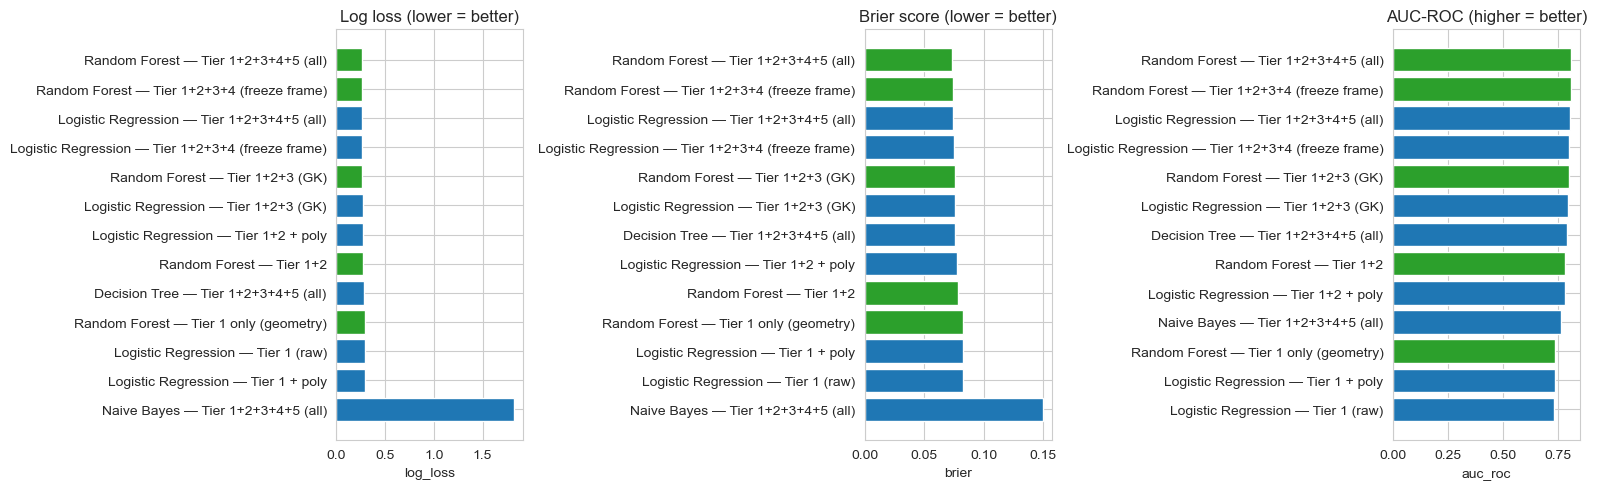

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_df = results_df.copy()
plot_df['label'] = plot_df['model'] + ' - ' + plot_df['tier']
plot_df = plot_df.sort_values('log_loss')

for ax, metric, asc in zip(axes, ['log_loss', 'brier', 'auc_roc'], [True, True, False]):
    sub = plot_df.sort_values(metric, ascending=asc)
    colors = ['#d62728' if 'XGBoost' in n else ('#2ca02c' if 'Random Forest' in n else '#1f77b4')
              for n in sub['model']]
    ax.barh(sub['label'], sub[metric], color=colors)
    ax.set_xlabel(metric)
    ax.invert_yaxis()

axes[0].set_title('Log loss (lower = better)')
axes[1].set_title('Brier score (lower = better)')
axes[2].set_title('AUC-ROC (higher = better)')

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/04a_baselines_metrics.png', dpi=140, bbox_inches='tight')
plt.show()
